# Projeto - Sprint 13

## 1. - Introdução & Pré Processamento

### 1.1 - Importação bibliotecas

In [ ]:
# pacotes necessários para o projeto
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans

### 1.2 - Importação tabela

In [ ]:
# leitura arquivo csv
gym_raw = pd.read_csv('/content/drive/MyDrive/bootcamp/SPRINT_13/PROJECT/dataset/gym_churn_us.csv')

### 1.3 - Primeiras impressões

In [ ]:
# descoberta primeiras linhas dataframe
gym_raw.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [ ]:
# descoberta informações gerais dataframe
gym_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

* Não foram constatados valores ausentes;
* A nomenclatura das colunas pode ser aprimorada;
* Os tipos de dados não carecem de substituição.



### 1.4 - Nomenclatura de colunas

In [ ]:
# cópia dataframe bruto
gym = gym_raw.copy()

In [ ]:
# adoção método snake_case
gym.columns = gym.columns.str.strip().str.lower()

### 1.5 - Checagem duplicados

In [ ]:
# teste duplicados
gym.duplicated().sum()

np.int64(0)

Não foram encontrados dados duplicados,

## 2. - EDA

### 2.1 - Olhe para o conjunto de dados: ele contém alguma característica ausente? Estude a média de valores e desvio padrão (use o método describe()).

In [ ]:
# descoberta características dados
gym.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
near_location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


Não foram constatados valores ausentes.

* gender - entradas distibuídas equilibradamente;

* near_location - entradas com predomínio de '1';

* partner - entradas distribuídas equilibradamente;

* promo_friends - entradas com predomínio de '0';

* phone - entradas com predeomínio de '1';

* contract_period - entradas com média de aproximadamente 5 meses de contrato, contudo cerca de 50% dos dados representam contratos de apenas 1 mês;

* group_visits - entradas com leve predomínio de '0';

* age - entradas com média de 29 anos, valor correspondente também à mediana;

* avg_additional_charges_total - entradas com média de 147, valor próximo à mediana.

* month_to_end_contract - entradas com média aproximada de 4 meses de contrato restantes, contudo cerca de 50% dos dados representam contratos a  apenas 1 mês do término.

* lifetime - entradas com média aproximada 4 de meses para lifetime de clientes, valor próximo também da mediana.

* avg_class_frequency_total - entradas com média aproximada de 2 idas por semana por cliente, valor também próximo da mediana.

* avg_class_frequency_current_month - entradas entradas com média aproximada de 2 idas por semana por cliente, valor também próximo da mediana.

* churn - entradas com predomínio de '0'.

### 2.2 - Observe a média dos valores médios das características em dois grupos: para aqueles que ficaram (use o método groupby()).

In [ ]:
# filtro dataframe com base em churn
churn_agg = gym.groupby('churn').agg({'gender': 'mean', 'near_location': 'mean', 'partner': 'mean', 'promo_friends': 'mean', 'phone': 'mean', 'contract_period': 'mean', 'group_visits': 'mean', 'age': 'mean', 'avg_additional_charges_total': 'mean', 'month_to_end_contract': 'mean', 'lifetime': 'mean', 'avg_class_frequency_total': 'mean', 'avg_class_frequency_current_month': 'mean'}).reset_index()
churn_agg

,churn,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
0,0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


Dentre as principais diferenças entre as médias de características que podem ser visualizadas entre os clientes que deixaram no mês em questão comparados aos que permaneceram, pode-se destacar:

* near_location - tendência de localização mais distante da academia;

* partner - tendência inferior de cliente ser colaborador de companhia parceira;

* promo_friends - tendência inferior de inscrição através da oferta "traga um amigo";

* contract_period - tendência de contrato mais curto;

* group_visits - tendência de menor participação de sessões em grupo;

* age - tendência de clientes mais jovens;

* avg_additional_charges_total - tendência de menor quantidade de dinheiro gasto em serviços extras;

* month_to_end_contract - tendência de contratos mais próximos do fim;

* lifetime - tendência de clientes adquiridos a menor tempor;

* avg_class_frequency_total - tendência de frequência total inferior;

* avg_class_frequency_current_month - tendência de frequência mensal inferior;

### 2.3 - Faça histogramas de barra e distribuições de características para aqueles que saíram (rotatividade) e aqueles que ficaram.

In [ ]:
# divisão colunas categóricas e contínuas
categorical_cols = ['gender', 'near_location', 'partner', 'promo_friends', 'phone', 'group_visits', 'churn']
continuous_cols = [col for col in gym.columns if col not in categorical_cols]

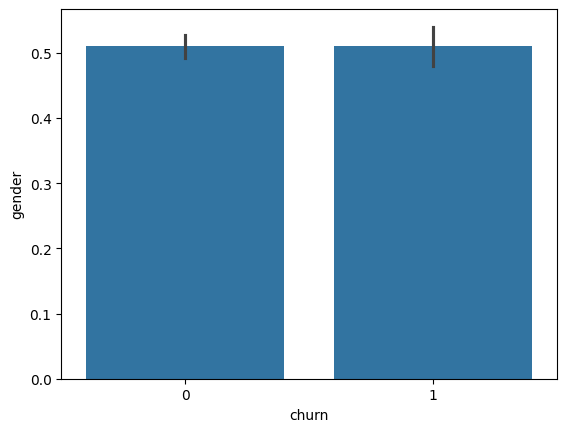

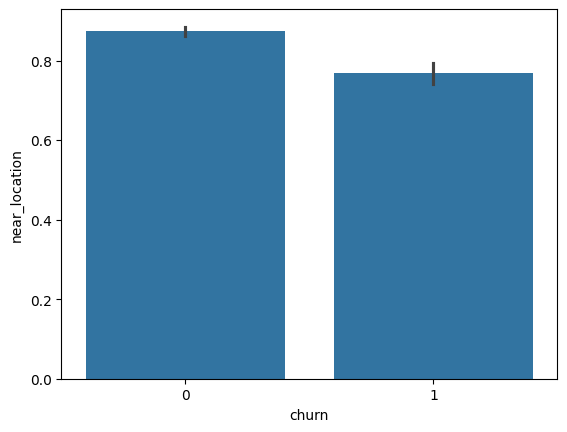

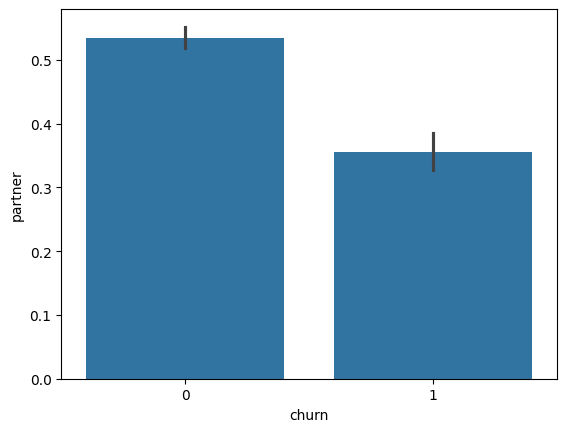

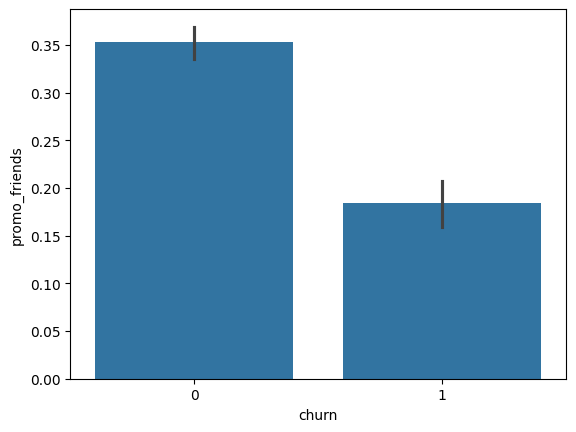

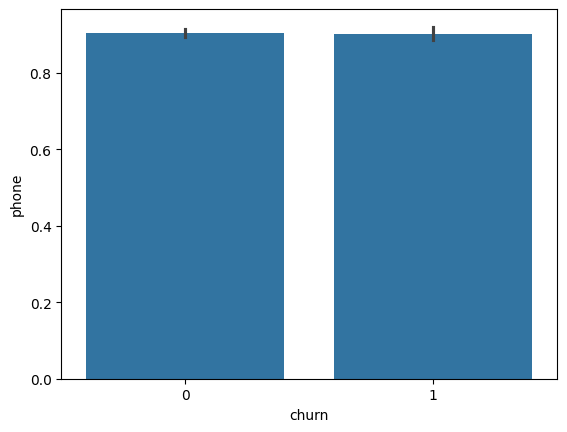

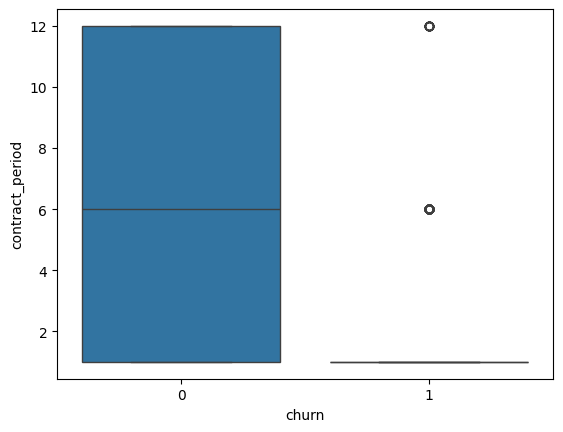

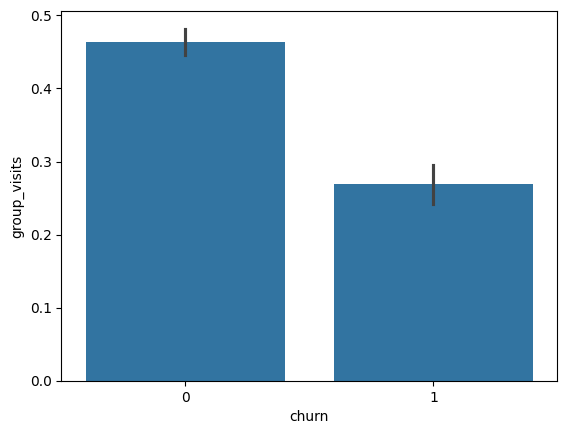

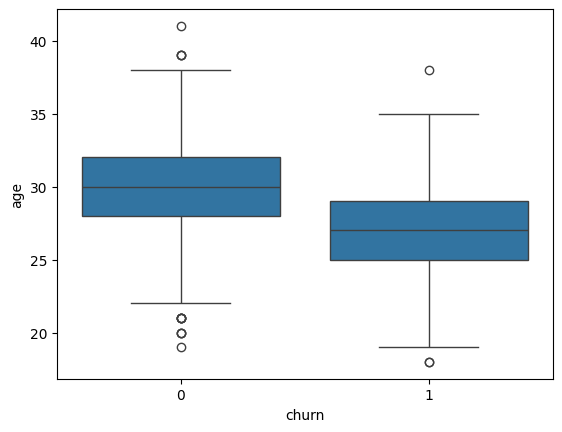

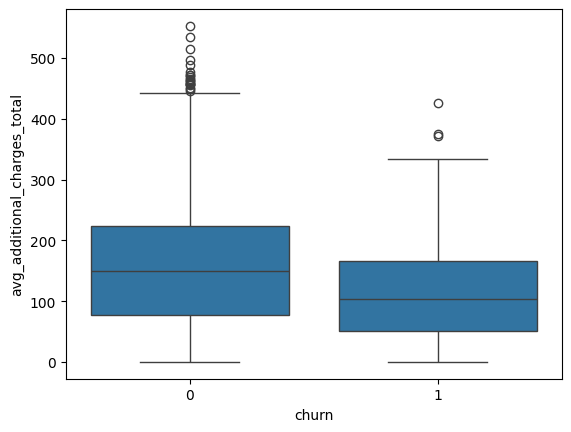

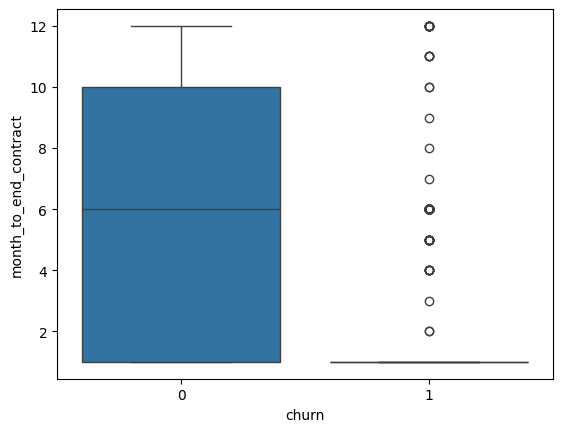

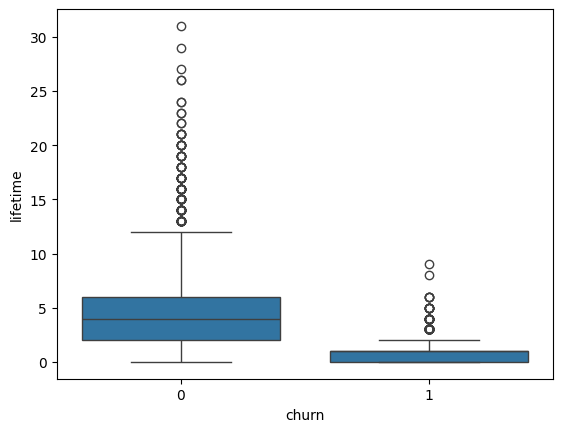

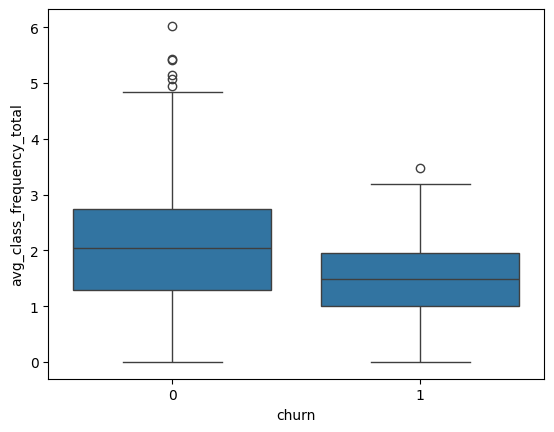

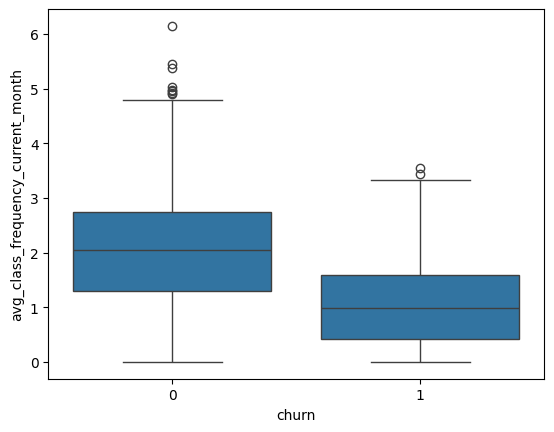

In [ ]:
# barras sobre características com base em churn
for column in gym.drop('churn', axis=1).columns:
  if column in categorical_cols:
    sns.barplot(data=gym, x='churn', y=column)
    plt.show()
  elif column in continuous_cols:
    sns.boxplot(data=gym, x='churn', y=column)
    plt.show()

### 2.4 - Construa a matriz de correlação e a exiba.

In [ ]:
# construção de matriz de correlação
corr_matrix = gym.corr()

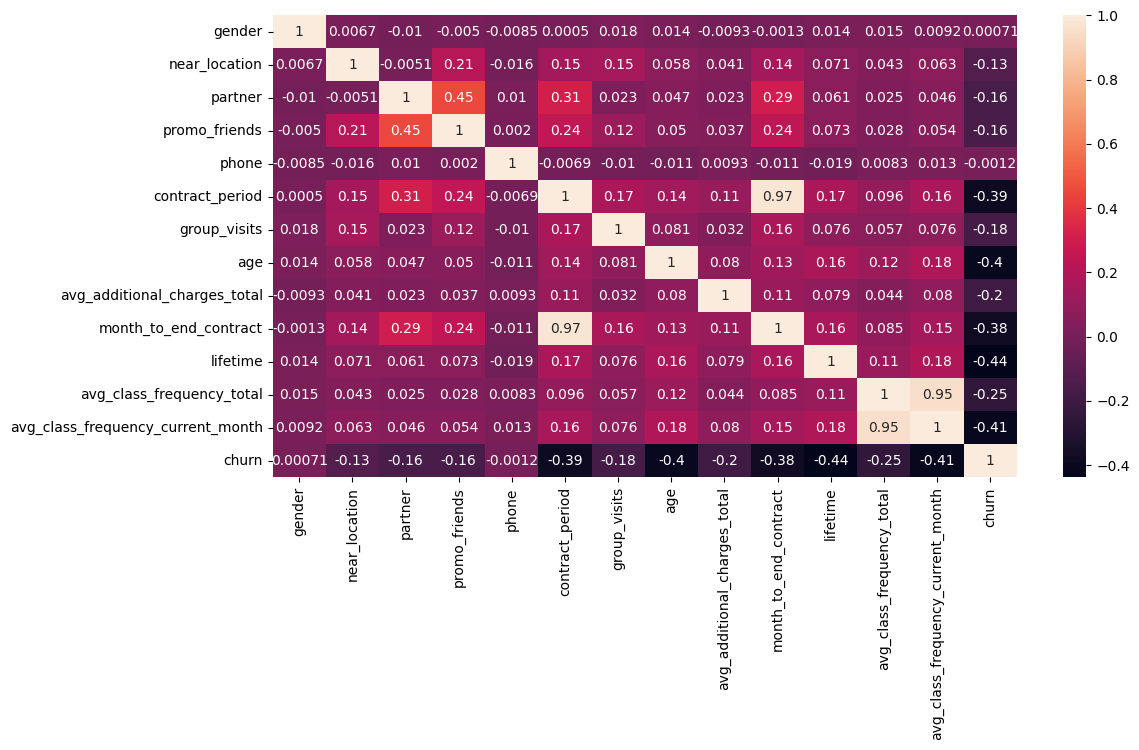

In [ ]:
# construção heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()

## 3. - Construa um modelo para predizer a rotatividade de clientes

Construa um modelo de classificação binária para clientes onde a variável objetivo é a saída de usuários do próximo mês.

### 3.1 - Treine o modelo no conjunto com dois métodos: regressão logística e floresta aleatória

In [ ]:
# divisão dados em características e variável objetivo
X = gym.drop('churn', axis=1)
y = gym['churn']

In [ ]:
# divisão dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

#### 3.1.1 - Regressão Logistíca

In [ ]:
# definição algoritmo treinamento
lr_model = LogisticRegression()

In [ ]:
# treinamento modelo
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# uso do modelo para predições
lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)[:,1]

#### 3.1.2 - Floresta Aleatória

In [ ]:
# treinamento StandardScaler no conjunto de treinamento
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [ ]:
# transformação conjuntos de treinamento e teste
X_train_st = scaler.transform(X_train)
X_test_st = scaler.transform(X_test)

In [ ]:
# definição algoritmo novo modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

In [ ]:
# treinamento novo modelo
rf_model.fit(X_train_st, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
# uso do modelo treinado para previsões
rf_predictions = rf_model.predict(X_test_st)
rf_probabilities = rf_model.predict_proba(X_test_st)[:,1]

### 3.2 - Avalie acurácia, precisão e sensibilidade para ambos os modelos usando dados de validação. Use-os para comparar os modelos. Qual modelo rendeu melhores resultados?

In [ ]:
# impressão métricas regressão logistíca
print('Métricas para Regressão Logística -')
print(f'Acurácia: {accuracy_score(y_test, lr_predictions):.2f}')
print(f'Precisão: {precision_score(y_test, lr_predictions):.2f}')
print(f'Sensibilidade: {recall_score(y_test, lr_predictions):.2f}')
print(f'F1: {f1_score(y_test, lr_predictions):.2f}')
print(f'ROC_AUC: {roc_auc_score(y_test, lr_probabilities):.2f}')

Métricas para Regressão Logística -
Acurácia: 0.91
Precisão: 0.82
Sensibilidade: 0.80
F1: 0.81
ROC_AUC: 0.96


In [ ]:
# impressão métricas floresta aleatória
print(f'Métricas para Floresta Aleatória - ')
print(f'Acurácia: {accuracy_score(y_test, rf_predictions):.2f}')
print(f'Precisão: {precision_score(y_test, rf_predictions):.2f}')
print(f'Sensibilidade: {recall_score(y_test, rf_predictions):.2f}')
print(f'F1: {f1_score(y_test, rf_predictions):.2f}')
print(f'ROC_AUC: {roc_auc_score(y_test, rf_probabilities):.2f}')

Métricas para Floresta Aleatória - 
Acurácia: 0.92
Precisão: 0.84
Sensibilidade: 0.81
F1: 0.83
ROC_AUC: 0.97


Todas as métricas analisadas do modelo Floresta Aleatória são ligeiramente superiores se comparadas aos resultados obtivos através do modelo Regressão Logistíca - inclusive a métrica ROC_AUC, que transmite o máximo de informação sobre a qualidade de um modelo.



## 4. - Crie agrupamentos de clientes

Defina ao lado colunas com dados sobre rotatividade e identifique agrupamentos do objeto (cliente):

### 4.1 - Padronize os dados.

In [ ]:
# padronização dadsos
sc = StandardScaler()
x_sc = sc.fit_transform(gym)

### 4.2 - Use a função linkage() para construir a matriz das distâncias baseada na matriz de características padronizada e construa um dendrograma. Perceba: renderizar o dendrograma pode demorar um tempo! Use o gráfico resultante para estimar o número de agrupamentos que você pode destacar.

In [ ]:
# aplicação função linkage para dados padronizados
linked = linkage(x_sc, method='ward')

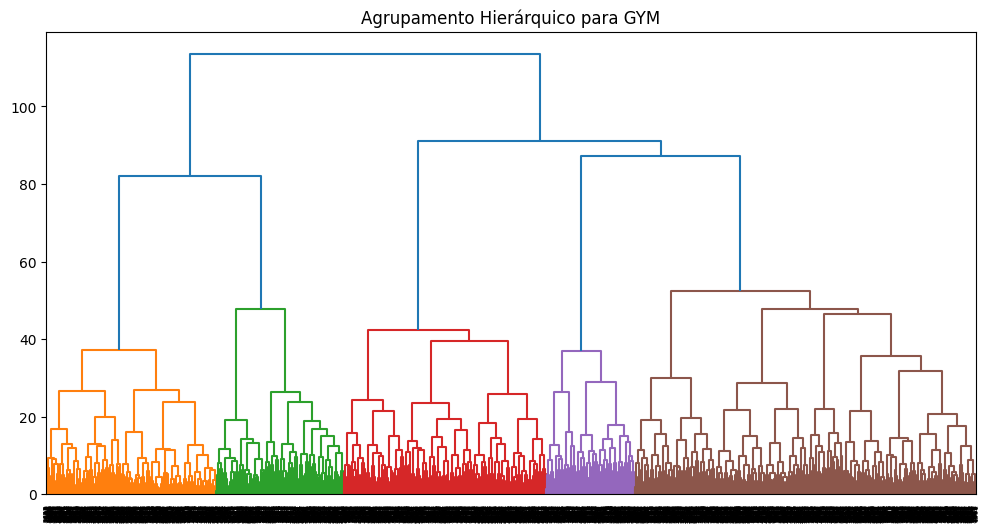

In [ ]:
# construção dendograma
plt.figure(figsize=(12,6))
dendrogram(linked, orientation='top')
plt.title('Agrupamento Hierárquico para GYM')
plt.show()

### 4.3 - Treine o modelo de agrupamento com o algoritmo K-means e preveja agrupamentos de clientes. (Deixe que o número de agrupamentos seja n=5,para que seja fácil comparar seus resultados com os de outros estudantes. No entanto, na vida real, ninguém vai te dar essas dicas, para que você tenha que decidir baseados nos gráficos das etapas anteriores.)

In [ ]:
# definição modelo kmeans com 5 agrupamentos
km = KMeans(n_clusters=5)

In [ ]:
# aplicação do algoritmo aos dados e formação de vetor de agrupamento
labels = km.fit_predict(x_sc)

In [ ]:
# armazenamento rótulos de agrupamento no campo dos dados
gym['cluster_km'] = labels

### 4.4 - Olhe para os valores médios das características para agrupamentos. Nada chama a sua atenção?

In [ ]:
# descoberta média de características por agrupamento
km_gym = gym.groupby(['cluster_km']).mean().reset_index()
km_gym

,cluster_km,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
0,0,0.509091,1.000000,0.333766,0.228571,1.000000,1.644156,0.285714,26.916883,115.058748,1.592208,1.070130,1.399798,1.006000,0.928571
1,1,0.504942,0.956873,0.787960,0.567835,1.000000,10.549865,0.537287,29.884996,159.558825,9.605571,4.615454,1.994920,1.988876,0.013477
2,2,0.526042,0.867188,0.471354,0.307292,0.000000,4.796875,0.429688,29.328125,144.408268,4.484375,3.960938,1.862114,1.731358,0.263021
3,3,0.497110,0.000000,0.462428,0.077071,0.996146,2.287091,0.215800,28.545279,136.048617,2.156069,2.832370,1.726813,1.550053,0.435453
4,4,0.516474,0.999176,0.322900,0.220758,1.000000,2.214168,0.456343,30.207578,161.061529,2.086491,4.898682,2.147134,2.150452,0.003295


Possível observar previsões de agrupamentos com tendências de churn (variável objetivo) extremamente opostas.

### 4.5 - Faça distribuições de características para os agrupamentos. Você notou alguma coisa?

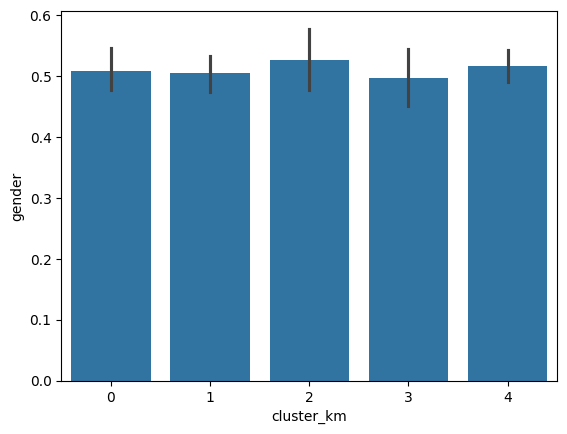

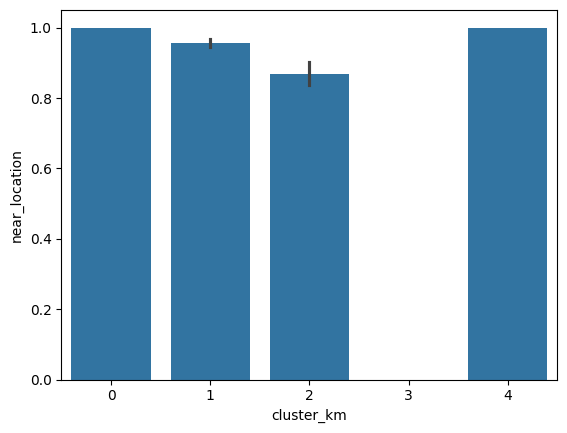

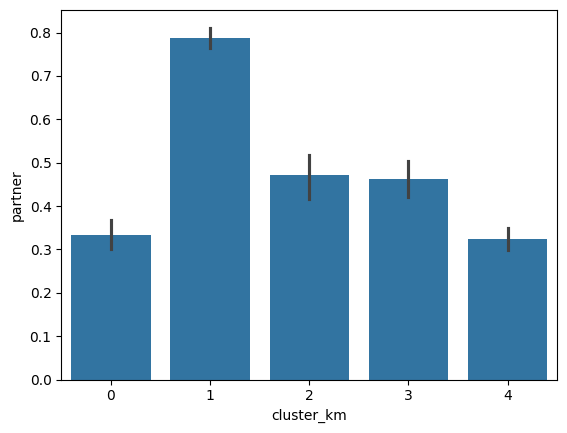

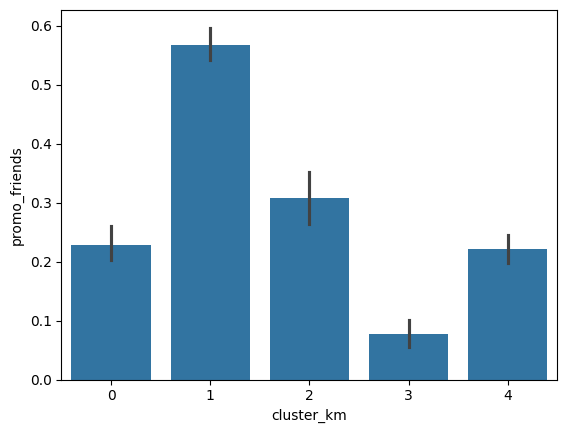

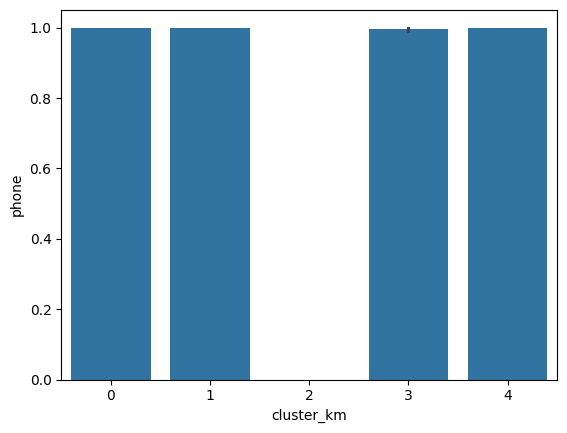

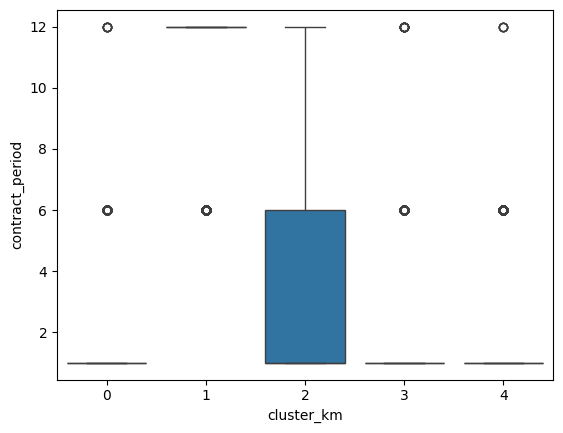

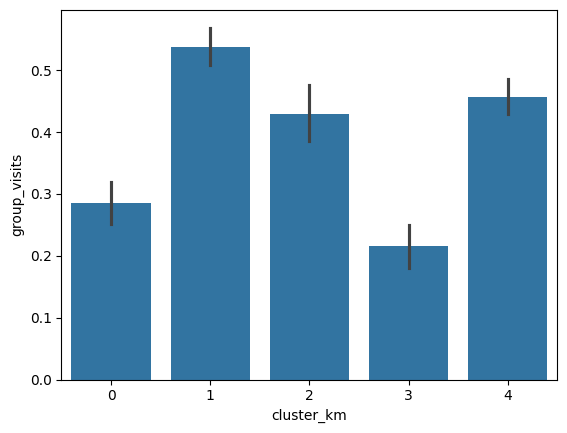

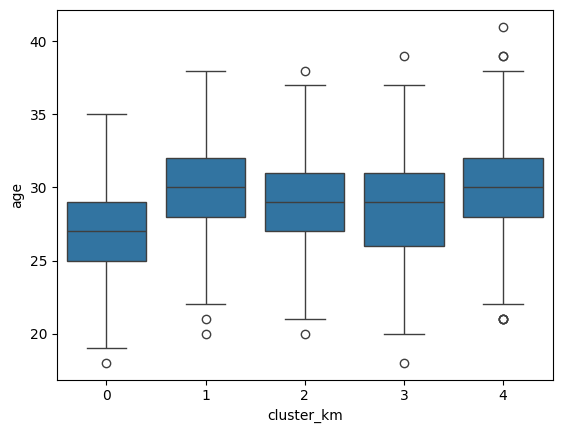

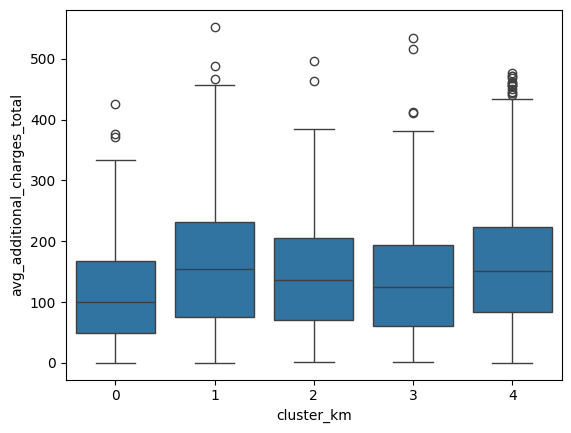

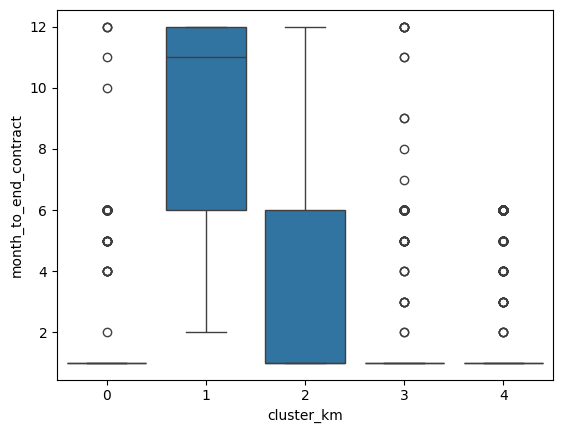

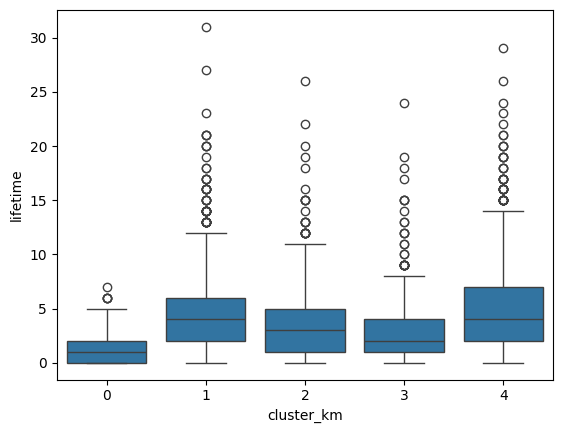

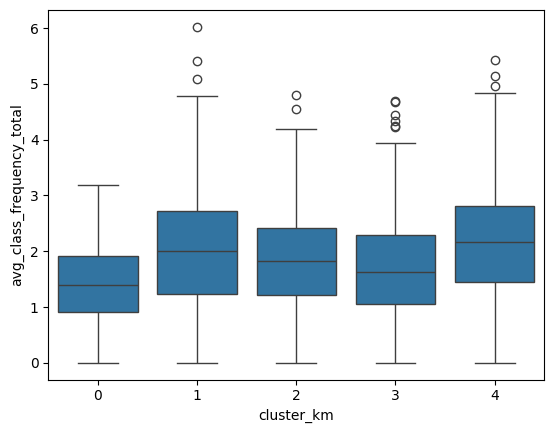

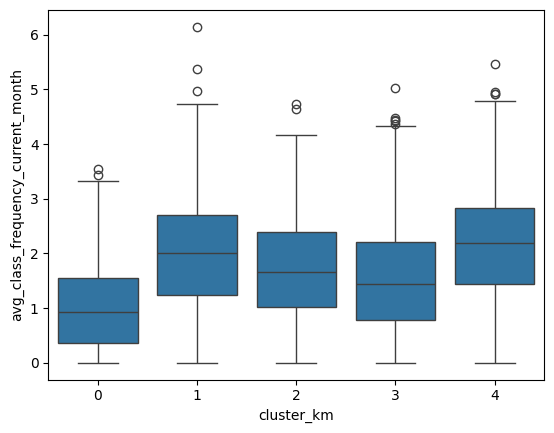

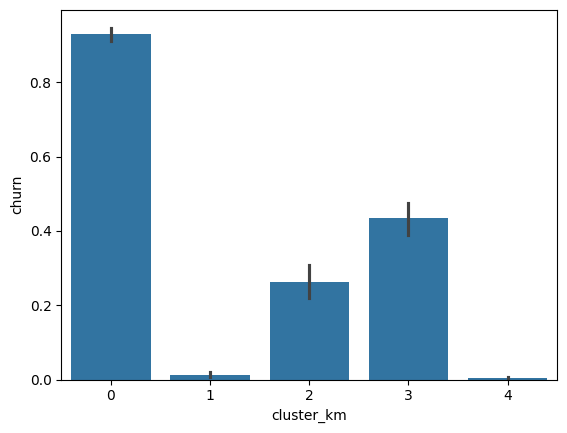

In [ ]:
# construção gráficos sobre características
for column in gym.drop('cluster_km', axis=1).columns:
  if column in categorical_cols:
    sns.barplot(data=gym, x='cluster_km', y=column)
    plt.xticks(gym['cluster_km'].unique())
    plt.show()
  elif column in continuous_cols:
    sns.boxplot(data=gym, x='cluster_km', y=column)
    plt.xticks(gym['cluster_km'].unique())
    plt.show()

Podemos observar tendências comportamentais entre os grupos:

Grupo 0 - Grupo sinal 'verde' com tendência baixa de rotatividade: se caracteriza por tendências de localização próxima, colaborador de companhia parceira, inscrição por código amigo, contratos longo, sessões em grupo, gastos extras maiores, cliente longevo, e menor número de visita semanal.

Grupo 1 - Grupo sinal 'verde' com tendência baixa de rotatividade: se caracteriza por tendências de localização próxima, não colaborador de companhia parceira, não inscrição por código amigo, contrato curto, sessões em grupo, gastos extras maiores, cliente longevo, e alto número de visitas semanais.

Grupo 2 - Grupo sinal 'amarelo' com tendência considerável de rotatividade: se caracteriza por tendências de localização mais distante, não inscrição por código amigo, contratos mais curtos, menor número de sessões em grupo, gastos extras médios, cliente recente, e número médio de visitas semanais.

Grupo 3 - Grupo sinal 'verde' com tendência baixa de rotatividade: se caracteriza por tendências de localização próxima, colaborador de companhia parceira, inscrição por código amigo, contrato longo, maior número de sessões em grupo, altos gastos extras, cliente longevo, e número médio de visitas semanais dos mais altos.

Grupo 4 - Grupo sinal 'vermelho' com maior tendência de rotatividade: se caracteriza por tendências de localização próxima, não colaborador de companhia parceira, não inscrição por código amigo, contrato curto, menor número de sessões em grupo, menor número de gastos extras, cliente recente, e número médio de visitas semanais baixo, em corrente queda.

### 4.6 - Calcule a taxa de rotatividade para cada agrupamento (use o método groupby()). Eles diferem em termos de taxa de rotatividade? Quais agrupamentos são propensos a sair, e quais são leais?

In [ ]:
# descoberta
km_gym[['cluster_km', 'churn']]

,cluster_km,churn
0,0,0.928571
1,1,0.013477
2,2,0.263021
3,3,0.435453
4,4,0.003295


Os agrupamentos que podem ser considerados leais são - 0, 1 e 3.

Os agrupamentos com maior propensão a sair são - 2 e 4.

## 5. -  Chegue a conclusões e faça recomendações básicas sobre trabalhar com clientes

Tirar conclusões e formular recomendações sobre a estratégia de interação e retenção de clientes.

Você não precisa entrar em detalhes. Três ou quatro princípios essenciais e exemplos da sua implementação na forma de passos de marketing específicos vai funcionar.

### 5.1 - Conclusão

De acordo com a análise realizada à partir da amostra de dados fornecida pela Model Fitness para prever a rotatividade de clientes do mês seguinte, pode-se chegar a algumas conclusões:

Foram identificados cinco perfis diferentes de clientes, contudo dois destes apresentam probabilidade elevada de desistência, sendo classificados por:

* Grupo Vermelho - Chance alta de desistência, se caracteriza por ser próximo geograficamente, não vinculado a companhias parceiras, menor lifetime entre grupos, contrato curto, índices de engajamento (inscrição com código amigo, sessões em grupo, consumo de serviços adicionais) e visitas abaixo.   

* Grupo Amarelo - Chance razoável de desistência, se caracteriza por ser  distante geograficamente, lifetime abaixo da média dos grupos, contrato curto, índices de engajamento (inscrição com código amigo, sessões em grupo, consumo de serviços adicionais) baixos e de visita um pouco mais elevados.


### 5.2 - Recomendações

À partir do entendimento sobre o perfil de cliente, é possível traçar planos e soluções que visam minimizar ou evitar a rotatividade:

Ambos os grupos apresentam similaridades: menores índices de engajamento (colaborador de empresa parceira, inscrição com código amigo, sessões em grupo, gastos com serviços extras).
Devem ser estímulados nestes grupos maior envolvimento dentro do universo da academia, para incentivo à sensação de pertencimento. Podem ser implementados convites especiais para sessões em grupo, melhores ofertas para consumo de serviços adicionais, descontos extras por fidelidade, entre outros.
São clientes onde a maioria não faz parte de uma companhia parceira e não ingressou através de um código amigo (logo, tendem a ser mais isolados e também com menores vantagens comerciais)  

* Grupo Vermelho - De longe o grupo que merece maior atenção, e também maior potencial de virada. Com a aplicação correta das recomendações, sentirão mais confortáveis aumentar suas frequências e consequentemente renovar os contratos e firmar vínculos mais longos. A rotatividade aqui pode ser evitada.  

* Grupo Amarelo - O principal asterisco deste grupo é a localização da moradia/local de trabalho. Ainda com a aplicação adequada das recomendações, é um grupo que tende a rotacionar mais que os demais. É um grupo que é preciso maximizar o lifetime. A rotatividade aqui pode ser minimizada.